# Task-3 Working in Teams – Simple Ensemble Concepts

To introduce the power of combining multiple simple models to achieve a more robust and accurate prediction. Learners will explore the fundamental ideas behind ensemble methods, such as voting classifiers or averaging predictions, and appreciate their advantage over single models.

In [3]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Create sample dataset
df = pd.DataFrame({
    'Sweetness': [7, 6, 8, 3, 2, 4, 9, 8, 3, 2],
    'Crunchiness': [6, 7, 8, 3, 2, 4, 9, 7, 3, 2],
    'Quality': [1, 1, 1, 0, 0, 0, 1, 1, 0, 0]
})

# Select features and target
X = df[['Sweetness', 'Crunchiness']]
y = df['Quality']

# Split the data
X_train_ensemble, X_test_ensemble, y_train_ensemble, y_test_ensemble = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale the data
scaler_ensemble = StandardScaler()

X_train_scaled_ensemble = scaler_ensemble.fit_transform(X_train_ensemble)
X_test_scaled_ensemble = scaler_ensemble.transform(X_test_ensemble)

print("Data split and scaled for ensemble modeling.")

Data split and scaled for ensemble modeling.


In [4]:
# 1. Logistic Regression
clf1 = LogisticRegression(random_state=1, solver='liblinear')

# 2. K-Nearest Neighbors
clf2 = KNeighborsClassifier(n_neighbors=5)

# 3. Decision Tree Classifier
clf3 = DecisionTreeClassifier(max_depth=3, random_state=1)

print("Individual classifiers defined.")

Individual classifiers defined.


In [5]:
# Step 2: Create and Train the Voting Classifier

# Create a VotingClassifier
clf1 = VotingClassifier(
    estimators=[
        ('lr', clf1),
        ('knn', clf2),
        ('dt', clf3)
    ],
    voting='hard'
)

# Train the ensemble model
clf1 = clf1.fit(X_train_scaled_ensemble, y_train_ensemble)

print("Voting Classifier (hard voting) trained successfully.")

Voting Classifier (hard voting) trained successfully.


In [6]:
# Step 3: Make Predictions and Evaluate the Ensemble Model

# Make predictions with the ensemble model
y_pred_ensemble = clf1.predict(X_test_scaled_ensemble)

# Evaluate the ensemble model's performance
ensemble_accuracy = accuracy_score(y_test_ensemble, y_pred_ensemble)
ensemble_report = classification_report(
    y_test_ensemble,
    y_pred_ensemble
)

print(f"Ensemble Model Accuracy: {ensemble_accuracy:.2f}")
print("Ensemble Model Classification Report:\n", ensemble_report)

Ensemble Model Accuracy: 1.00
Ensemble Model Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



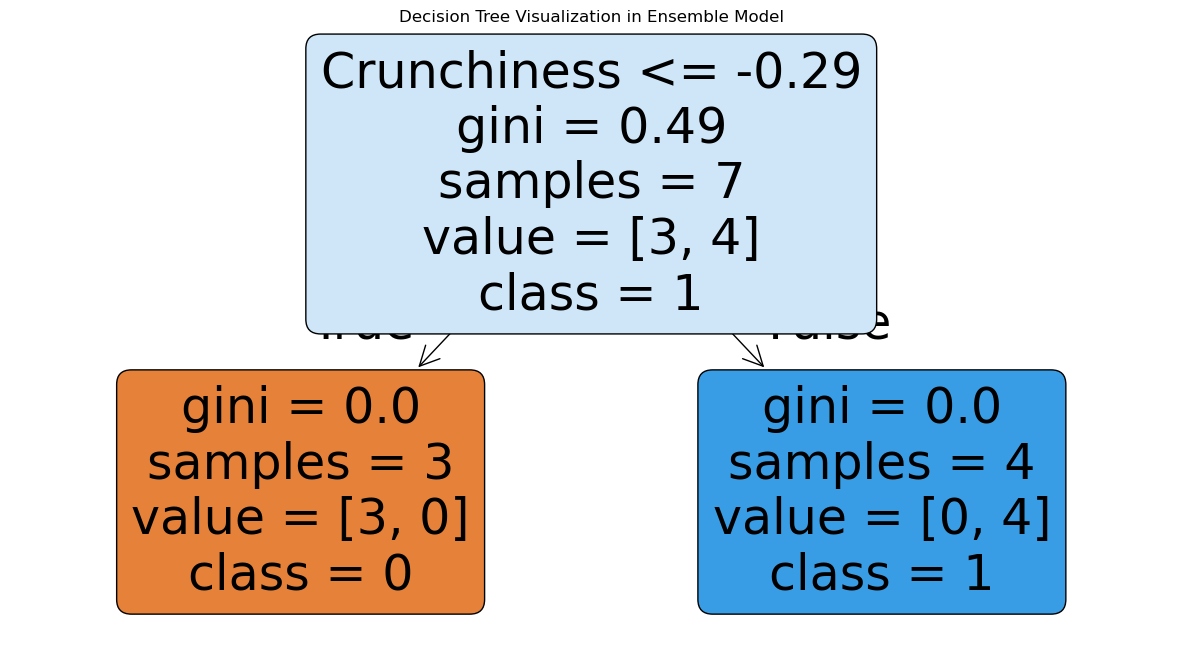

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

dt_model = clf1.estimators_[2]

plt.figure(figsize=(15, 8))

plot_tree(
    dt_model,
    feature_names=['Sweetness', 'Crunchiness'],
    class_names=['0', '1'],
    filled=True,
    rounded=True
)

plt.title('Decision Tree Visualization in Ensemble Model')
plt.show()

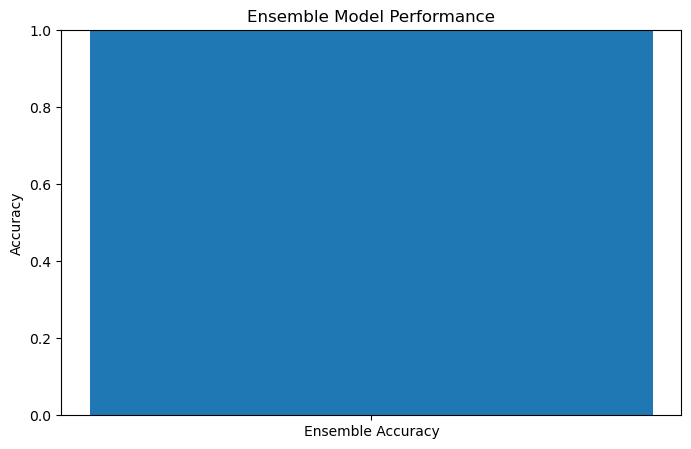

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    ['Ensemble Accuracy'],
    [ensemble_accuracy]
)

plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Ensemble Model Performance')
plt.show()

# Visualization

The Decision Tree is visualized using plot_tree() to show its decision-making structure. The ensemble model performance is also visualized using a bar chart based on its accuracy.